# 3.1 导读与数学基础：经典算法

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

在进入协同过滤、MF、FM 与 GBDT+LR 前，建立邻域、低秩、特征交互和二分类概率的共同数学地图。

## Setup

本 Notebook 的默认真实数据是 **GroupLens MovieLens latest-small：经典评分与邻域任务**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [GroupLens](https://dl.acm.org/doi/10.1145/192844.192905) · [ItemCF](https://dl.acm.org/doi/10.1145/371920.372071) · [MF](https://datajobs.com/data-science-repo/Recommender-Systems-[Netflix].pdf) · [FM](https://www.csie.ntu.edu.tw/~b97053/paper/Rendle2010FM.pdf) · [GBDT+LR](https://research.facebook.com/publications/practical-lessons-from-predicting-clicks-on-ads-at-facebook/)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance)
DATASET_KEY = "movielens"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 子章节 | 解决的问题 | 共同数学 | 典型位置 |
|---|---|---|---|
| 3.1.1 UserCF / ItemCF | 借相似用户或物品的行为推荐 | 矩阵、点积、余弦、加权和 | 召回、相关推荐 |
| 3.1.2 BiasMF | 用低维坐标压缩稀疏评分矩阵 | 矩阵乘法、内积、均方误差 | 召回、评分预测 |
| 3.1.3 FM | 学习稀疏 field 的二阶交互 | one-hot、向量内积、LogLoss | CTR 排序 |
| 3.1.4 GBDT+LR | 用树规则产生特征并预测点击概率 | 条件分支、one-hot、Sigmoid | CTR 排序 |
| 3.1 总结 | 从实际 JSON 汇总指标 | 指标方向与公平比较 | 选型 |

应用场景并非互斥：ItemCF 常作为可解释兜底通道；MF 是向量召回的最小原型；FM 与 GBDT+LR 是成熟 CTR 基线。学习顺序建议从矩阵共现开始，再进入可训练表示和概率模型。

## 来源论文解读

- **Resnick et al. (1994)** 把相似用户评分加权落成可运行系统，核心遗产是“从群体行为借信号”。
- **Sarwar et al. (2001)** 把邻域转到更稳定的 item 侧，使相似表可以离线物化。
- **Koren et al. (2009)** 强调只在已观察集合上训练、加入用户/物品偏置并正则化低秩向量。
- **Rendle (2010)** 用共享隐向量估计从未共同出现过的稀疏特征组合。
- **He et al. (2014)** 把树当监督式特征变换，再由 LR 输出可校准概率。

这些论文对应两种数据生成机制：CF/MF 学 user–item 行为或评分；FM/GBDT+LR 学曝光后的点击。两类指标不能直接排名。

## 共同数学：一张矩阵，三种读法

设 $R\in\mathbb R^{|U|\times|I|}$ 是用户—物品矩阵。

1. **邻域：** $RR^\top$ 批量计算用户共现，$R^\top R$ 批量计算物品共现；余弦再消除长度影响。
2. **低秩：** $R\approx PQ^\top$，把每位用户和物品映射到 $d$ 维坐标。$P_u^\top Q_i$ 是两张坐标卡逐项相乘求和。
3. **稀疏交互：** FM 为 one-hot 特征配置向量，使用 $\langle v_i,v_j\rangle x_ix_j$ 表示任意两项交互。
4. **CTR 概率：** LR/GBDT+LR/FM 排序都可输出 logit $z$，再用 $\sigma(z)=1/(1+e^{-z})$ 得到概率，并以 LogLoss 训练。

先看形状，再看每个数字代表什么，比背公式更重要。

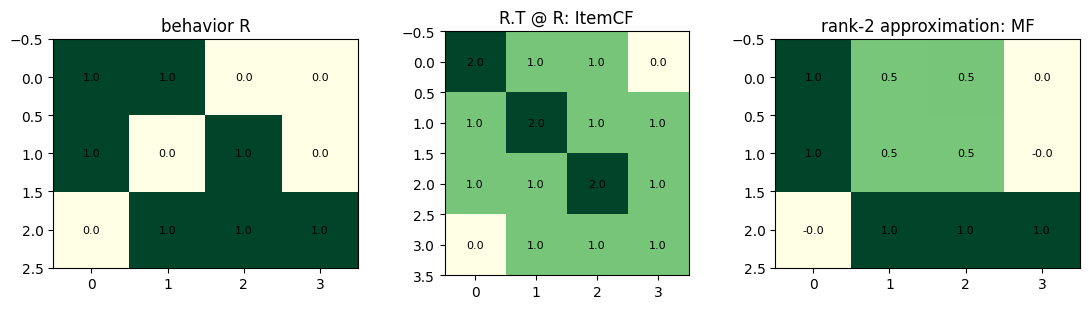

{'logit': [-2.0, 0.0, 2.0], 'sigmoid': [0.119, 0.5, 0.881]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
R=np.array([[1,1,0,0],[1,0,1,0],[0,1,1,1]],dtype=float)
user_common=R@R.T; item_common=R.T@R
u,s,vt=np.linalg.svd(R,full_matrices=False); rank2=(u[:,:2]*s[:2])@vt[:2]
fig,axes=plt.subplots(1,3,figsize=(11,3.2))
for ax,matrix,title in [(axes[0],R,'behavior R'),(axes[1],item_common,'R.T @ R: ItemCF'),(axes[2],rank2,'rank-2 approximation: MF')]:
    ax.imshow(matrix,cmap='YlGn'); ax.set_title(title)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]): ax.text(col,row,f'{matrix[row,col]:.1f}',ha='center',va='center',fontsize=8)
plt.tight_layout(); plt.show()
z=np.array([-2.,0.,2.]); print({'logit':z.tolist(),'sigmoid':(1/(1+np.exp(-z))).round(3).tolist()})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
assert user_common.shape==(3,3)
assert item_common.shape==(4,4)
assert rank2.shape==R.shape
print('PASS：共现、低秩近似和概率变换的基础形状正确。')

PASS：共现、低秩近似和概率变换的基础形状正确。


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。